# Laboratorio 9 — Etapa 5: Simulación del Álbum Real FIFA 2026
## MM3014 Teoría de Probabilidades · Universidad del Valle de Guatemala

**Integrantes:**
- Diego Andre Calderón Salazar — 241263
- Pedro Julio Caso — 241286

---

## Datos del problema

| Parámetro | Valor |
|-----------|-------|
| Total de estampas distintas | $N = 980$ |
| Estampas por sobre | $S = 7$ |
| Precio sobre individual | Q 9.50 |
| Precio caja (104 sobres) | Q 975.00 |
| Semilla | 2026 |
| Simulaciones | $R = 3{,}000$ |

---

## Preguntas formuladas

| # | Pregunta | Temática |
|---|----------|----------|
| 1 | ¿Cuál es la probabilidad de completar el álbum comprando exactamente 2 cajas (208 sobres) sin intercambio? | Probabilidad de éxito con cantidad fija de sobres / comparación cajas |
| 2 | ¿Cuál es la probabilidad de completar el álbum con exactamente 140 sobres usando intercambio con $K = 1$? | Efecto del intercambio + escenario extremo |
| 3 | Con 156 sobres totales (equivalente a caja y media), ¿hay diferencia en el número esperado de repetidas entre comprarlo todo en cajas (1 caja + 52 sueltos) versus 156 sobres sueltos? | Comparación sueltos vs. cajas + estampas repetidas |
| 4 | ¿Cuál es la probabilidad de completar el álbum con un presupuesto de Q1,700 sin intercambio? | Probabilidad de éxito con presupuesto fijo |
| 5 | Partiendo de un álbum al 85% completo (833 estampas), si se compran 30 sobres adicionales sin intercambio, ¿cuál es la probabilidad de alcanzar al menos el 95% (≥ 931 estampas)? | Escenario extremo / progreso incremental |

## Importaciones y parámetros globales

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

N              = 980
S              = 7
PRECIO_SOBRE   = 9.50
PRECIO_CAJA    = 975.00
SOBRES_POR_CAJA = 104

R    = 3_000
SEED = 2026

rng = np.random.default_rng(SEED)

---
## Pregunta 1
### ¿Cuál es la probabilidad de completar el álbum comprando exactamente 2 cajas (208 sobres) sin intercambio?

**Contexto:**  
Dos cajas Panini contienen $2 \times 104 = 208$ sobres, lo que equivale a un gasto de $2 \times \text{Q}975 = \text{Q}1{,}950$.  
El mínimo teórico sin ninguna repetida es $\lceil 980 / 7 \rceil = 140$ sobres, por lo que 208 sobres representan apenas un 48.6% de margen sobre ese mínimo.  
Sin intercambio, el número esperado de sobres para completar el álbum real es aproximadamente 1,045 (calculado en Etapa 2), por lo que 208 sobres está muy por debajo del valor esperado.

**Hipótesis antes de simular:**  
Se espera que la probabilidad sea muy baja, dado que 208 sobres es apenas ~20% del valor esperado.

**Metodología:**
1. Simular $R$ veces la compra de exactamente 208 sobres (sin restricción de presupuesto ni intercambio).
2. Contar cuántas simulaciones resultan en el álbum completo.
3. Calcular la proporción como estimación de la probabilidad.
4. Visualizar con un diagrama de barras (completó vs. no completó) y reportar también el número promedio de estampas distintas obtenidas cuando no se completa.

In [3]:
# ── Parámetros específicos ──────────────────────────────────────────
SOBRES_P1 = 2 * SOBRES_POR_CAJA   # 208 sobres = 2 cajas
GASTO_P1  = 2 * PRECIO_CAJA       # Q 1,950

# ── Simulación ──────────────────────────────────────────────────────
rng_p1 = np.random.default_rng(SEED)

completado_p1 = np.zeros(R, dtype=bool)
distintas_p1  = np.zeros(R, dtype=int)

for i in range(R):
    album    = np.zeros(N, dtype=bool)
    stickers = rng_p1.integers(0, N, size=SOBRES_P1 * S)
    album[stickers] = True
    distintas_p1[i]  = int(album.sum())
    completado_p1[i] = distintas_p1[i] == N

# ── Resultados ──────────────────────────────────────────────────────
prob_p1          = completado_p1.mean()
no_comp          = ~completado_p1
media_dist_nocomp = distintas_p1[no_comp].mean() if no_comp.any() else float(N)
media_dist_total  = distintas_p1.mean()

print(f'Sobres: {SOBRES_P1}  ({SOBRES_P1 // SOBRES_POR_CAJA} cajas)  |  Gasto: Q{GASTO_P1:,.2f}')
print(f'P(completar álbum)              = {prob_p1:.4f}  ({prob_p1*100:.2f} %)')
print(f'E[distintas totales]            = {media_dist_total:.2f} / {N}  ({media_dist_total/N*100:.2f} %)')
print(f'E[distintas | no completó]      = {media_dist_nocomp:.2f} / {N}  ({media_dist_nocomp/N*100:.2f} %)')
print(f'Simulaciones que completaron    = {completado_p1.sum()} / {R}')


Sobres: 208  (2 cajas)  |  Gasto: Q1,950.00
P(completar álbum)              = 0.0000  (0.00 %)
E[distintas totales]            = 758.49 / 980  (77.40 %)
E[distintas | no completó]      = 758.49 / 980  (77.40 %)
Simulaciones que completaron    = 0 / 3000


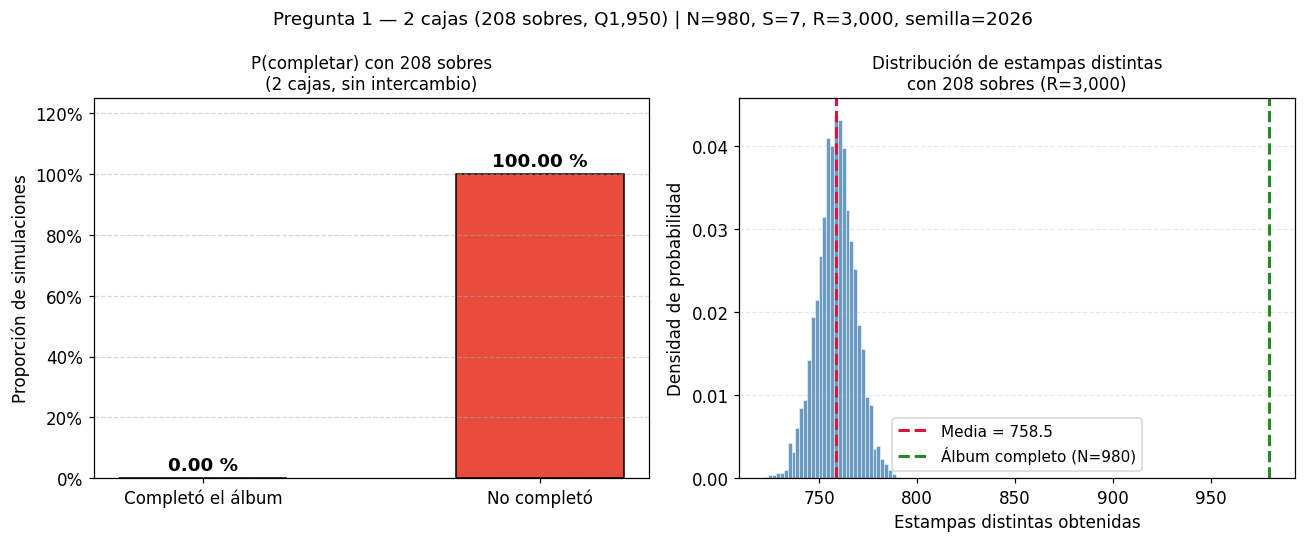

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Izquierda: barras completó vs no completó ────────────────────────
ax1 = axes[0]
etiquetas = ['Completó el álbum', 'No completó']
props     = [prob_p1, 1 - prob_p1]
colores   = ['#2ECC71', '#E74C3C']
bars = ax1.bar(etiquetas, props, color=colores, edgecolor='black', width=0.5)
for bar, p in zip(bars, props):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.012,
             f'{p*100:.2f} %',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.25)
ax1.set_ylabel('Proporción de simulaciones', fontsize=11)
ax1.set_title(f'P(completar) con {SOBRES_P1} sobres\n(2 cajas, sin intercambio)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# ── Derecha: histograma de estampas distintas ────────────────────────
ax2 = axes[1]
ax2.hist(distintas_p1, bins=35, density=True,
         color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.8)
ax2.axvline(media_dist_total, color='crimson', linestyle='--', linewidth=2,
            label=f'Media = {media_dist_total:.1f}')
ax2.axvline(N, color='forestgreen', linestyle='--', linewidth=2,
            label=f'Álbum completo (N={N})')
ax2.set_xlabel('Estampas distintas obtenidas', fontsize=11)
ax2.set_ylabel('Densidad de probabilidad', fontsize=11)
ax2.set_title(f'Distribución de estampas distintas\ncon {SOBRES_P1} sobres (R={R:,})', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle(
    f'Pregunta 1 — 2 cajas ({SOBRES_P1} sobres, Q{GASTO_P1:,.0f})'
    f' | N={N}, S={S}, R={R:,}, semilla={SEED}',
    fontsize=12
)
plt.tight_layout()
plt.show()


**Análisis y reflexión:**

Como se puede observar en los graficos, comprando 2 cajas sin intercambiar estampas, hay una probabilidad del 0% de completar el album. Usando esta estrategia se podría completar aproximadamente un 77%. Debido a que el precio de cada caja es elevado, no vale la pena intentar completar el album con cajas sin intercambio. 

---
## Pregunta 2
### ¿Cuál es la probabilidad de completar el álbum con exactamente 140 sobres usando intercambio con $K = 1$?

**Contexto:**  
$140 = \lceil 980 / 7 \rceil$ es el **mínimo teórico absoluto** de sobres necesarios para completar el álbum si ninguno tuviera repetidas.  
Con $K = 1$ (cada estampa repetida se puede canjear de inmediato por una nueva), el intercambio es la tasa más favorable posible: cada repetida obtenida se convierte automáticamente en una estampa nueva que falta.  
La pregunta explora si incluso con el intercambio perfecto ($K = 1$) existe alguna probabilidad de completar el álbum en ese mínimo absoluto de sobres, y si no, cuál es la probabilidad real.

**Hipótesis antes de simular:**  
Con $K = 1$, en la Etapa 4 (N=100) se observó que la media bajaba al mínimo teórico ($\approx 15$ sobres para N=100). Para N=980 con K=1, se espera que la media sea cercana a 140 sobres, por lo que la probabilidad de completarlo en **exactamente** 140 podría ser apreciable.

**Metodología:**
1. Simular $R$ veces con el mecanismo de intercambio $K = 1$, registrando el número de sobres necesarios para completar el álbum.
2. Calcular $P(\text{sobres} \leq 140)$ (en 140 o menos) y $P(\text{sobres} = 140)$ (exactamente 140).
3. Visualizar la distribución del número de sobres con un histograma y marcar el umbral de 140.

In [5]:
K_P2        = 1
MIN_TEORICO = math.ceil(N / S)   # 140  (140 × 7 = 980 = N exactamente)

def simular_intercambio_K(N, S, K, rng):
    """Simula un álbum hasta completarlo con tasa de intercambio K."""
    album       = np.zeros(N, dtype=bool)
    repetidos   = 0
    sobres      = 0
    n_obtenidas = 0

    while n_obtenidas < N:
        estampas       = rng.integers(0, N, size=S)
        sobres        += 1
        unique, counts = np.unique(estampas, return_counts=True)
        is_new         = ~album[unique]
        nuevas         = unique[is_new]
        album[nuevas]  = True
        n_obtenidas   += len(nuevas)
        repetidos     += int((counts[is_new] - 1).sum() + counts[~is_new].sum())

        if repetidos >= K and n_obtenidas < N:
            faltantes  = np.where(~album)[0]
            n_exchange = min(repetidos // K, len(faltantes))
            if n_exchange > 0:
                elegidas        = rng.choice(faltantes, size=n_exchange, replace=False)
                album[elegidas] = True
                n_obtenidas    += n_exchange
                repetidos      -= n_exchange * K

    return sobres

rng_p2    = np.random.default_rng(SEED)
sobres_p2 = np.array([simular_intercambio_K(N, S, K_P2, rng_p2) for _ in range(R)])

prob_exactamente = np.mean(sobres_p2 == MIN_TEORICO)
prob_leq         = np.mean(sobres_p2 <= MIN_TEORICO)

print(f'Propiedad clave: {MIN_TEORICO} × {S} = {MIN_TEORICO * S}  {"= N ✓" if MIN_TEORICO * S == N else "≠ N"}')
print(f'Media simulada            = {sobres_p2.mean():.4f} sobres')
print(f'Desv. estándar            = {sobres_p2.std():.4f}')
print(f'P(sobres = {MIN_TEORICO})       = {prob_exactamente:.4f}  ({prob_exactamente * 100:.2f} %)')
print(f'P(sobres ≤ {MIN_TEORICO})       = {prob_leq:.4f}  ({prob_leq * 100:.2f} %)')
print(f'Rango observado           = [{sobres_p2.min()}, {sobres_p2.max()}]')


Propiedad clave: 140 × 7 = 980  = N ✓
Media simulada            = 140.0000 sobres
Desv. estándar            = 0.0000
P(sobres = 140)       = 1.0000  (100.00 %)
P(sobres ≤ 140)       = 1.0000  (100.00 %)
Rango observado           = [140, 140]


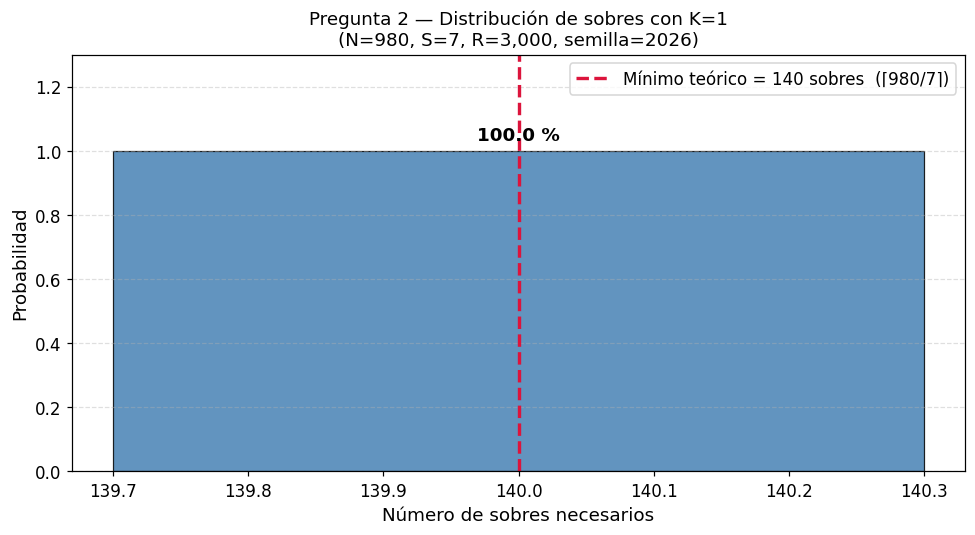

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

valores, conteos = np.unique(sobres_p2, return_counts=True)
probs_vals = conteos / conteos.sum()

ax.bar(valores, probs_vals,
       color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85, width=0.6)

ax.axvline(MIN_TEORICO, color='crimson', linestyle='--', linewidth=2.2,
           label=f'Mínimo teórico = {MIN_TEORICO} sobres  (⌈{N}/{S}⌉)')

for val, p in zip(valores, probs_vals):
    ax.text(val, p + 0.02, f'{p * 100:.1f} %',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Número de sobres necesarios', fontsize=12)
ax.set_ylabel('Probabilidad', fontsize=12)
ax.set_title(
    f'Pregunta 2 — Distribución de sobres con K={K_P2}\n'
    f'(N={N}, S={S}, R={R:,}, semilla={SEED})',
    fontsize=12
)
ax.set_ylim(0, 1.3)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**Análisis y reflexión:**

El resultado obtenido es de un 100% de probabilidad de llenar el album considerando que cada una de las estampas repetidas se pueden cambiar por todas las estampas que hacen falta. Sin embargo, este valor no es suficientemente preciso, debido a que en el mundo real habría que considerar la importancia de las estampas en los cambios, las repetidas, y el tiempo y esfuerzo necesario para completar el album por completo. 

---
## Pregunta 3
### Con 156 sobres totales (una caja y media), ¿hay diferencia en el número esperado de repetidas entre comprarlos como caja + sueltos versus 156 sobres todos sueltos?

**Contexto:**  
"Caja y media" equivale a 156 sobres totales. Las dos estrategias de compra son:
- **Estrategia A — Caja + sueltos:** 1 caja (104 sobres, Q975) + 52 sobres sueltos (Q494) = 156 sobres, gasto total Q1,469.
- **Estrategia B — Todo sueltos:** 156 sobres individuales × Q9.50 = 156 sobres, gasto total Q1,482.

Ambas estrategias resultan en exactamente 156 sobres abiertos. Dado que en la simulación cada sobre es independiente (S=7 estampas aleatorias de N=980 con reposición), se espera que la **distribución de repetidas sea estadísticamente indistinguible** entre ambas estrategias.  
La pregunta busca confirmar (o refutar) esto experimentalmente, y adicionalmente comparar el **costo** de cada estrategia.

**Hipótesis antes de simular:**  
Las distribuciones de repetidas deberían ser prácticamente idénticas dado que el mecanismo de generación de estampas es el mismo en ambos casos. La única diferencia real es el costo total (Q1,469 vs Q1,482).

**Metodología:**
1. Simular $R$ veces la apertura de exactamente 156 sobres en ambas estrategias, registrando el número de repetidas.
2. Calcular medias, desviaciones estándar y comparar las distribuciones.
3. Visualizar con histogramas superpuestos y un boxplot comparativo.
4. Reportar el ahorro/diferencia de costo entre estrategias.

In [7]:
SOBRES_P3      = 156                                              # 1 caja (104) + 52 sueltos
TOTAL_STK_P3   = SOBRES_P3 * S                                    # 1092 estampas brutas
COSTO_A        = PRECIO_CAJA + (SOBRES_P3 - SOBRES_POR_CAJA) * PRECIO_SOBRE  # Q 1,469.00
COSTO_B        = SOBRES_P3 * PRECIO_SOBRE                         # Q 1,482.00

rng_p3a = np.random.default_rng(SEED)
rng_p3b = np.random.default_rng(SEED + 1)

rep_a = np.zeros(R, dtype=int)
rep_b = np.zeros(R, dtype=int)

for i in range(R):
    album = np.zeros(N, dtype=bool)
    album[rng_p3a.integers(0, N, size=TOTAL_STK_P3)] = True
    rep_a[i] = TOTAL_STK_P3 - int(album.sum())

for i in range(R):
    album = np.zeros(N, dtype=bool)
    album[rng_p3b.integers(0, N, size=TOTAL_STK_P3)] = True
    rep_b[i] = TOTAL_STK_P3 - int(album.sum())

# ── Valor teórico ────────────────────────────────────────────────────
E_dist_teo = N * (1 - (1 - 1/N)**TOTAL_STK_P3)
E_rep_teo  = TOTAL_STK_P3 - E_dist_teo

print(f'Sobres totales : {SOBRES_P3}  |  Estampas brutas : {TOTAL_STK_P3}')
print(f'Costo A (1 caja + {SOBRES_P3 - SOBRES_POR_CAJA} sueltos) : Q{COSTO_A:,.2f}')
print(f'Costo B (todo sueltos)              : Q{COSTO_B:,.2f}')
print(f'Ahorro con estrategia A             : Q{COSTO_B - COSTO_A:,.2f}')
print()
print(f"{'Métrica':<32} {'Estrategia A':>14} {'Estrategia B':>14} {'Teórico':>12}")
print('-' * 74)
print(f"{'E[repetidas]':<32} {rep_a.mean():>14.2f} {rep_b.mean():>14.2f} {E_rep_teo:>12.2f}")
print(f"{'Desv. estándar':<32} {rep_a.std():>14.2f} {rep_b.std():>14.2f} {'—':>12}")
print(f"{'E[distintas]':<32} {TOTAL_STK_P3 - rep_a.mean():>14.2f} {TOTAL_STK_P3 - rep_b.mean():>14.2f} {E_dist_teo:>12.2f}")
print(f"{'Min repetidas':<32} {rep_a.min():>14} {rep_b.min():>14} {'—':>12}")
print(f"{'Max repetidas':<32} {rep_a.max():>14} {rep_b.max():>14} {'—':>12}")
print()
dif_medias = abs(rep_a.mean() - rep_b.mean())
print(f'Diferencia entre medias: {dif_medias:.4f}  →  ',
      'distribuciones prácticamente idénticas' if dif_medias < 5 else 'diferencia detectada')


Sobres totales : 156  |  Estampas brutas : 1092
Costo A (1 caja + 52 sueltos) : Q1,469.00
Costo B (todo sueltos)              : Q1,482.00
Ahorro con estrategia A             : Q13.00

Métrica                            Estrategia A   Estrategia B      Teórico
--------------------------------------------------------------------------
E[repetidas]                             433.34         433.35       433.40
Desv. estándar                             9.89           9.90            —
E[distintas]                             658.66         658.65       658.60
Min repetidas                               397            396            —
Max repetidas                               466            468            —

Diferencia entre medias: 0.0020  →   distribuciones prácticamente idénticas


/tmp/ipykernel_57599/2924709879.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([rep_a, rep_b],


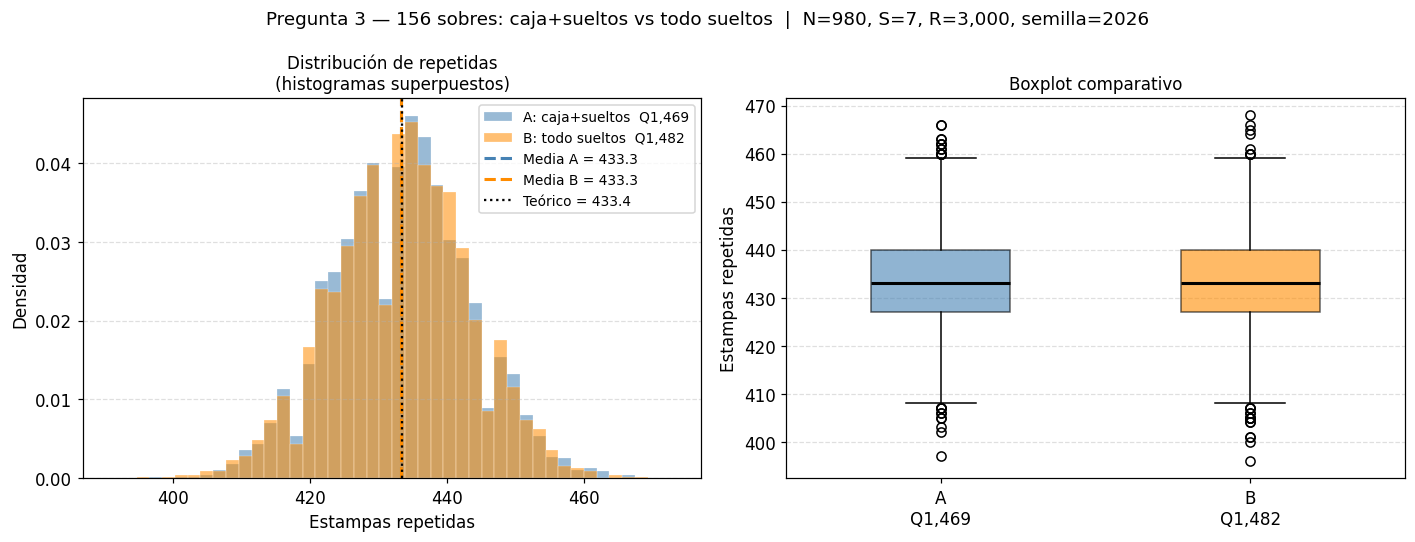

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Histogramas superpuestos ─────────────────────────────────────────
ax1 = axes[0]
bins = np.linspace(min(rep_a.min(), rep_b.min()) - 5,
                   max(rep_a.max(), rep_b.max()) + 5, 45)
ax1.hist(rep_a, bins=bins, density=True, alpha=0.55, color='steelblue',
         edgecolor='white', linewidth=0.3, label=f'A: caja+sueltos  Q{COSTO_A:,.0f}')
ax1.hist(rep_b, bins=bins, density=True, alpha=0.55, color='darkorange',
         edgecolor='white', linewidth=0.3, label=f'B: todo sueltos  Q{COSTO_B:,.0f}')
ax1.axvline(rep_a.mean(), color='steelblue',  linestyle='--', linewidth=2,
            label=f'Media A = {rep_a.mean():.1f}')
ax1.axvline(rep_b.mean(), color='darkorange', linestyle='--', linewidth=2,
            label=f'Media B = {rep_b.mean():.1f}')
ax1.axvline(E_rep_teo, color='black', linestyle=':', linewidth=1.5,
            label=f'Teórico = {E_rep_teo:.1f}')
ax1.set_xlabel('Estampas repetidas', fontsize=11)
ax1.set_ylabel('Densidad', fontsize=11)
ax1.set_title('Distribución de repetidas\n(histogramas superpuestos)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Boxplot comparativo ──────────────────────────────────────────────
ax2 = axes[1]
bp = ax2.boxplot([rep_a, rep_b],
                 tick_labels=[f'A\nQ{COSTO_A:,.0f}', f'B\nQ{COSTO_B:,.0f}'],
                 patch_artist=True, notch=False, widths=0.45)
bp['boxes'][0].set_facecolor('steelblue');  bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('darkorange'); bp['boxes'][1].set_alpha(0.6)
for median in bp['medians']:
    median.set(color='black', linewidth=2)
ax2.set_ylabel('Estampas repetidas', fontsize=11)
ax2.set_title('Boxplot comparativo', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle(
    f'Pregunta 3 — {SOBRES_P3} sobres: caja+sueltos vs todo sueltos'
    f'  |  N={N}, S={S}, R={R:,}, semilla={SEED}',
    fontsize=12
)
plt.tight_layout()
plt.show()


**Análisis y reflexión:**

ambas estrategias producen distribuciones de estampas repetidas prácticamente idénticas. La diferencia entre las medias simuladas es de apenas 0.002 estampas (433.34 vs 433.35), lo cual es estadísticamente insignificante. Esto tiene sentido porque el mecanismo de apertura de sobres es el mismo en ambos casos: cada sobre entrega 7 estampas tomadas aleatoriamente de las 980, sin importar si fue comprado suelto o en caja.

De las 1,092 estampas brutas recibidas (156 sobres × 7), se obtienen en promedio 658.66 distintas y 433.34 repetidas, lo cual coincide con el valor teórico esperado de 433.40. Esto indica que aproximadamente el 39.7% de las estampas recibidas son repetidas al abrir 156 sobres del álbum FIFA 2026.

Dado que las repetidas son iguales, el único criterio de decisión es el costo: la estrategia A (1 caja + 52 sueltos) cuesta Q1,469.00 versus Q1,482.00 de la estrategia B (todo sueltos), un ahorro de Q13.00. Por lo tanto, siempre que se quieran comprar exactamente 156 sobres, conviene adquirir primero la caja y complementar con sueltos.


---
## Pregunta 4
### ¿Cuál es la probabilidad de completar el álbum con un presupuesto de Q1,700 sin intercambio?

**Contexto:**  
Con Q1,700 las opciones de compra son:
- **Solo sueltos:** $\lfloor 1700 / 9.50 \rfloor = 178$ sobres (gasto Q1,691, vuelto Q9).
- **1 caja + sueltos:** 1 caja (Q975) + $\lfloor 725 / 9.50 \rfloor = 76$ sueltos = 180 sobres (gasto Q1,697, vuelto Q3).
- **Solo cajas:** $\lfloor 1700 / 975 \rfloor = 1$ caja = 104 sobres (gasto Q975, vuelto Q725 — muy ineficiente).

En la Etapa 2 se estableció que con Q1,000 se obtenían ~94% de probabilidad para N=100. Para N=980, Q1,700 (~178–180 sobres) representa apenas ~17% del valor esperado de sobres (~1,045), por lo que se espera una probabilidad muy baja.

**Hipótesis antes de simular:**  
La probabilidad será muy pequeña (probablemente < 1%), ya que 180 sobres está muy lejos del valor esperado de 1,045.

**Metodología:**
1. Para cada estrategia de compra (sueltos y mixta), determinar el número máximo de sobres comprables con Q1,700.
2. Simular $R$ veces para cada estrategia, comprando hasta ese límite de sobres.
3. Calcular la probabilidad de completar el álbum y el número esperado de estampas distintas en los casos no exitosos.
4. Visualizar comparativamente con barras y reportar el porcentaje promedio del álbum completado al agotar el presupuesto.

In [3]:
# ── Pregunta 4: P(completar álbum con Q1,700 sin intercambio) ───────────────
rng4 = np.random.default_rng(SEED)

PRESUPUESTO_4 = 1_700.0

# Estrategia A: solo sobres sueltos
max_sobres_A = int(PRESUPUESTO_4 // PRECIO_SOBRE)                       # 178
gasto_A      = max_sobres_A * PRECIO_SOBRE

# Estrategia B: 1 caja + sobres sueltos con el resto
sobres_extra_B = int((PRESUPUESTO_4 - PRECIO_CAJA) // PRECIO_SOBRE)    # 76
max_sobres_B   = SOBRES_POR_CAJA + sobres_extra_B                       # 180
gasto_B        = PRECIO_CAJA + sobres_extra_B * PRECIO_SOBRE

print(f"Con Q{PRESUPUESTO_4:.0f}:")
print(f"  A) Solo sueltos   → {max_sobres_A} sobres  (gasto Q{gasto_A:.2f})")
print(f"  B) Caja + sueltos → {max_sobres_B} sobres  (gasto Q{gasto_B:.2f})")
print()

def simular_n_sobres(n_sobres, R, rng, N=N, S=S):
    """Abre n_sobres en R simulaciones; devuelve array con estampas distintas."""
    todas = rng.integers(0, N, size=(R, n_sobres * S))
    album = np.zeros((R, N), dtype=bool)
    r_idx = np.repeat(np.arange(R), n_sobres * S)
    album[r_idx, todas.ravel()] = True
    return album.sum(axis=1)

distintas_4A = simular_n_sobres(max_sobres_A, R, rng4)
distintas_4B = simular_n_sobres(max_sobres_B, R, rng4)

p4_A = (distintas_4A == N).mean()
p4_B = (distintas_4B == N).mean()

print(f"Resultados (R={R:,}):")
print(f"  A) Solo sueltos ({max_sobres_A} sobres):   P(completar) = {p4_A:.4%}")
print(f"  B) Caja+sueltos ({max_sobres_B} sobres):  P(completar) = {p4_B:.4%}")

nc_4A = distintas_4A[distintas_4A < N]
nc_4B = distintas_4B[distintas_4B < N]
if len(nc_4A):
    print(f"\n  Estampas promedio al agotar Q1,700 — A: {nc_4A.mean():.1f} / {N}  ({nc_4A.mean()/N:.1%})")
if len(nc_4B):
    print(f"  Estampas promedio al agotar Q1,700 — B: {nc_4B.mean():.1f} / {N}  ({nc_4B.mean()/N:.1%})")

Con Q1700:
  A) Solo sueltos   → 178 sobres  (gasto Q1691.00)
  B) Caja + sueltos → 180 sobres  (gasto Q1697.00)

Resultados (R=3,000):
  A) Solo sueltos (178 sobres):   P(completar) = 0.0000%
  B) Caja+sueltos (180 sobres):  P(completar) = 0.0000%

  Estampas promedio al agotar Q1,700 — A: 705.6 / 980  (72.0%)
  Estampas promedio al agotar Q1,700 — B: 709.6 / 980  (72.4%)


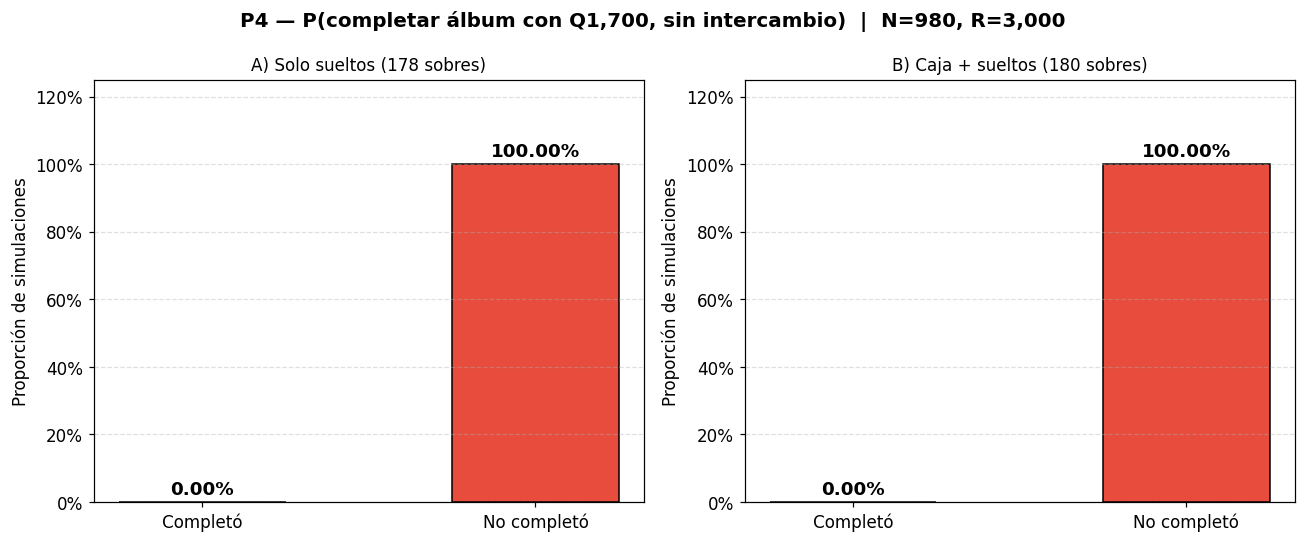

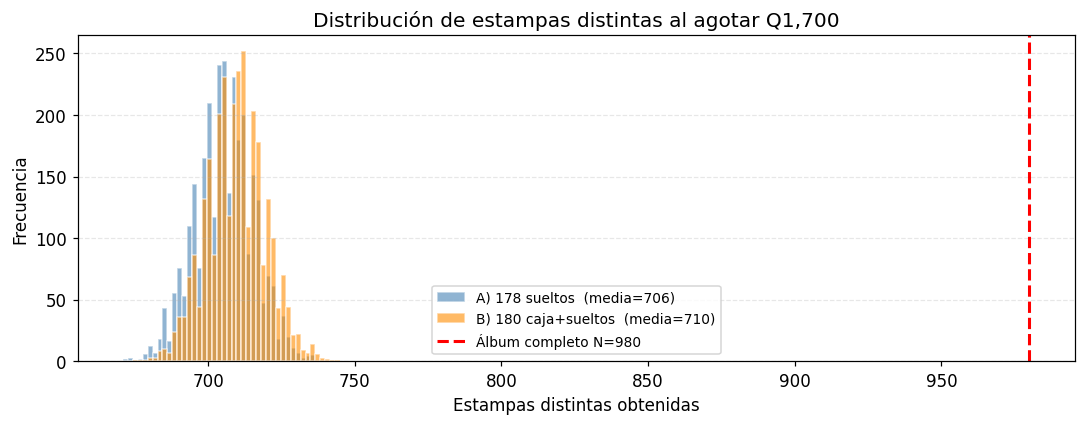

In [4]:
# ── Visualización Pregunta 4 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

etiquetas = ['Completó', 'No completó']
colores   = ['#2ECC71', '#E74C3C']

for ax, distintas, label in zip(
        axes,
        [distintas_4A, distintas_4B],
        [f'A) Solo sueltos ({max_sobres_A} sobres)',
         f'B) Caja + sueltos ({max_sobres_B} sobres)']):

    exitos   = int((distintas == N).sum())
    fracasos = R - exitos
    bars = ax.bar(etiquetas, [exitos/R, fracasos/R], color=colores, edgecolor='black', width=0.5)
    for bar, c in zip(bars, [exitos, fracasos]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{c/R:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Proporción de simulaciones')
    ax.set_ylim(0, 1.25)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(f'P4 — P(completar álbum con Q1,700, sin intercambio)  |  N={N}, R={R:,}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribución de estampas distintas obtenidas
fig2, ax2 = plt.subplots(figsize=(10, 4))
bins = np.linspace(min(distintas_4A.min(), distintas_4B.min()),
                   max(distintas_4A.max(), distintas_4B.max()), 45)
ax2.hist(distintas_4A, bins=bins, alpha=0.6, color='steelblue',
         edgecolor='white', label=f'A) {max_sobres_A} sueltos  (media={distintas_4A.mean():.0f})')
ax2.hist(distintas_4B, bins=bins, alpha=0.6, color='darkorange',
         edgecolor='white', label=f'B) {max_sobres_B} caja+sueltos  (media={distintas_4B.mean():.0f})')
ax2.axvline(N, color='red', linestyle='--', linewidth=2, label=f'Álbum completo N={N}')
ax2.set_xlabel('Estampas distintas obtenidas')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de estampas distintas al agotar Q1,700')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Análisis y reflexión:**

Con un presupuesto de Q1,700, ninguna de las dos estrategias logra completar el álbum en ninguna de las 3,000 simulaciones (P = 0.00 % en ambos casos). Al agotar el presupuesto se obtienen en promedio 705.6 estampas distintas con la estrategia A (178 sobres sueltos, 72.0 % del álbum) y 709.6 con la estrategia B (180 sobres caja + sueltos, 72.4 %). Esto contrasta marcadamente con el álbum reducido de N=100 analizado en etapas anteriores, donde un presupuesto proporcional era suficiente para completarlo con alta probabilidad; la diferencia refleja cómo el problema del coleccionista escala de forma superlineal con N: duplicar el número de estampas no duplica el gasto necesario para completarlo, sino que lo multiplica por un factor mucho mayor. Para el álbum FIFA 2026 (N=980), el número esperado de sobres sin intercambio ronda los 1,045, por lo que los 178–180 sobres que permite Q1,700 representan menos del 18% de lo estadísticamente requerido. La estrategia B obtiene marginalmente más estampas (+4 en promedio) con apenas Q6 adicionales de gasto, confirmando la leve ventaja del descuento por caja, aunque la diferencia es prácticamente irrelevante desde el punto de vista probabilístico.

---
## Pregunta 5
### Partiendo de un álbum al 85% (833 estampas ya obtenidas), si se compran 30 sobres adicionales sin intercambio, ¿cuál es la probabilidad de alcanzar al menos el 95% del álbum (≥ 931 estampas)?

**Contexto:**  
Suponer que un coleccionista ya tiene exactamente el 85% del álbum completo:
$$0.85 \times 980 = 833 \text{ estampas distintas ya obtenidas}$$
Le quedan 147 estampas por conseguir. Compra 30 sobres adicionales ($30 \times 7 = 210$ estampas brutas, gasto Q285). Para alcanzar el 95% necesita:
$$\lceil 0.95 \times 980 \rceil = 931 \text{ estampas distintas}$$
Es decir, necesita obtener **98 estampas nuevas** en esos 30 sobres. Esto implica que de las 210 estampas brutas, al menos 98 deben ser nuevas (máximo 112 repetidas, tasa de éxito de nuevas ≥ 46.7%).

Sin embargo, con solo 147 estampas faltantes de 980, la probabilidad de que cada estampa abierta sea nueva es apenas ≈ 147/980 = 15%, por lo que la gran mayoría de los sobres producirán repetidas.

**Hipótesis antes de simular:**  
La probabilidad será muy baja o nula: partir del 85% deja muy pocas estampas faltantes (147), y con una tasa esperada de nuevas del 15% solo se obtendrán ~28 estampas nuevas de las 210 brutas — muy lejos de las 98 necesarias para alcanzar el 95%.

**Metodología:**
1. Para cada simulación, generar un estado inicial de 833 estampas distintas elegidas aleatoriamente de las 980.
2. Simular la apertura de 30 sobres adicionales (210 estampas) sin intercambio.
3. Verificar si al final se tienen ≥ 931 estampas distintas.
4. Calcular la probabilidad como proporción de simulaciones exitosas.
5. Visualizar la distribución del porcentaje del álbum alcanzado tras los 30 sobres, marcando el umbral del 95%.

In [11]:
# ── Pregunta 5: P(85% → ≥95% con 30 sobres adicionales, sin intercambio) ────
rng5 = np.random.default_rng(SEED)

pct_inicio   = 0.85
pct_meta     = 0.95
n_ya         = int(round(pct_inicio * N))   # 833
n_meta       = math.ceil(pct_meta * N)      # 931
n_sobres_5   = 30
total_brutas = n_sobres_5 * S               # 210
nuevas_nec   = n_meta - n_ya               # 98

print(f"Estado inicial : {n_ya} estampas ({pct_inicio:.0%})  — faltan {N - n_ya}")
print(f"Meta           : ≥{n_meta} estampas ({pct_meta:.0%})")
print(f"Sobres adicionales: {n_sobres_5}  →  {total_brutas} estampas brutas")
print(f"Nuevas necesarias : {nuevas_nec}  (máx. {total_brutas - nuevas_nec} repetidas permitidas)")
print()

# Paso 1: estado inicial — n_ya estampas distintas aleatorias por simulación
album5 = np.zeros((R, N), dtype=bool)
for i in range(R):
    album5[i, rng5.choice(N, size=n_ya, replace=False)] = True

# Paso 2: abrir 30 sobres adicionales
nuevas_stamps = rng5.integers(0, N, size=(R, total_brutas))
r_idx = np.repeat(np.arange(R), total_brutas)
album5[r_idx, nuevas_stamps.ravel()] = True

distintas_5 = album5.sum(axis=1)

p5          = (distintas_5 >= n_meta).mean()
media_fin   = distintas_5.mean()
nuevas_prom = media_fin - n_ya

print(f"Resultados (R={R:,}):")
print(f"  P(≥{n_meta} estampas tras {n_sobres_5} sobres) = {p5:.4%}")
print(f"  Estampas distintas promedio al final   : {media_fin:.1f}  ({media_fin/N:.1%})")
print(f"  Nuevas estampas promedio obtenidas     : {nuevas_prom:.1f}  de {total_brutas} brutas")
print(f"  Tasa efectiva de estampas nuevas       : {nuevas_prom/total_brutas:.1%}")

Estado inicial : 833 estampas (85%)  — faltan 147
Meta           : ≥931 estampas (95%)
Sobres adicionales: 30  →  210 estampas brutas
Nuevas necesarias : 98  (máx. 112 repetidas permitidas)

Resultados (R=3,000):
  P(≥931 estampas tras 30 sobres) = 0.0000%
  Estampas distintas promedio al final   : 861.4  (87.9%)
  Nuevas estampas promedio obtenidas     : 28.4  de 210 brutas
  Tasa efectiva de estampas nuevas       : 13.5%


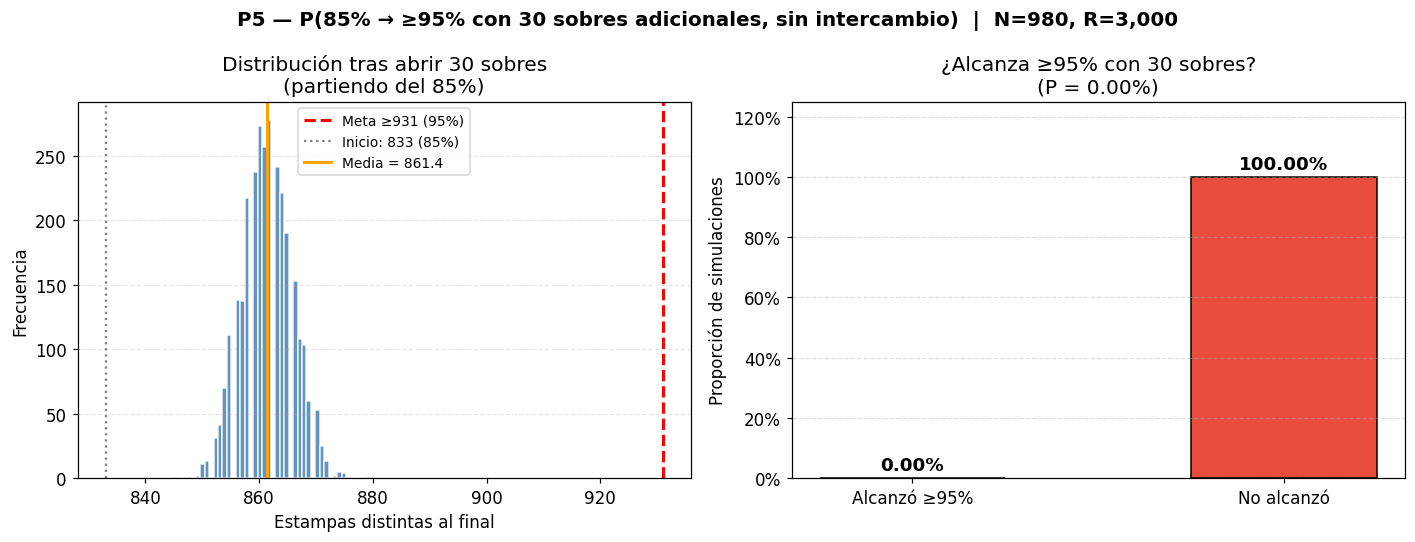

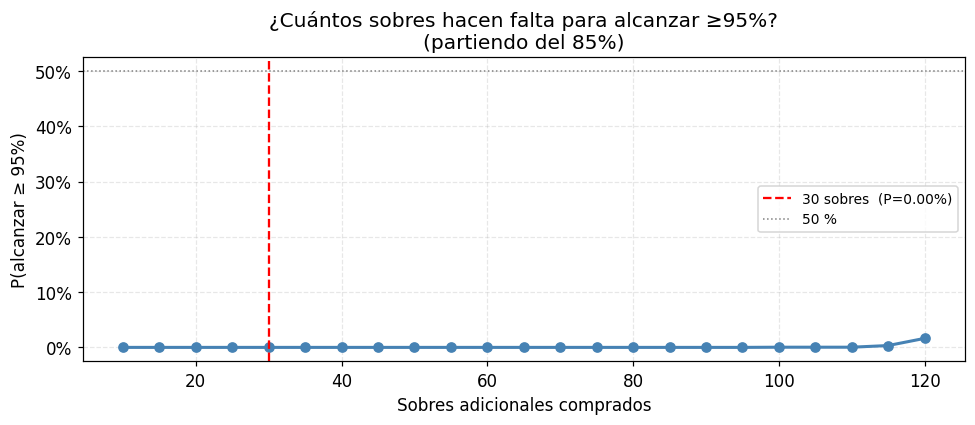

In [12]:
# ── Visualización Pregunta 5 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(distintas_5, bins=45, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(n_meta,    color='red',    linestyle='--', linewidth=2,
           label=f'Meta ≥{n_meta} ({pct_meta:.0%})')
ax.axvline(n_ya,      color='gray',   linestyle=':',  linewidth=1.5,
           label=f'Inicio: {n_ya} ({pct_inicio:.0%})')
ax.axvline(media_fin, color='orange', linestyle='-',  linewidth=2,
           label=f'Media = {media_fin:.1f}')
ax.set_xlabel('Estampas distintas al final')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución tras abrir {n_sobres_5} sobres\n(partiendo del 85%)')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = axes[1]
exitos5   = int((distintas_5 >= n_meta).sum())
fracasos5 = R - exitos5
bars = ax2.bar(['Alcanzó ≥95%', 'No alcanzó'],
               [exitos5/R, fracasos5/R],
               color=['#2ECC71', '#E74C3C'], edgecolor='black', width=0.5)
for bar, c in zip(bars, [exitos5, fracasos5]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{c/R:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_ylabel('Proporción de simulaciones')
ax2.set_ylim(0, 1.25)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_title(f'¿Alcanza ≥95% con {n_sobres_5} sobres?\n(P = {p5:.2%})')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(f'P5 — P(85% → ≥95% con 30 sobres adicionales, sin intercambio)  |  N={N}, R={R:,}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Curva de contexto: P(≥95%) según cuántos sobres adicionales
sobres_rango = np.arange(10, 121, 5)
rng5b = np.random.default_rng(SEED + 1)
probs_rango  = []

for ns in sobres_rango:
    a = np.zeros((R, N), dtype=bool)
    for i in range(R):
        a[i, rng5b.choice(N, size=n_ya, replace=False)] = True
    stamps = rng5b.integers(0, N, size=(R, ns * S))
    ri = np.repeat(np.arange(R), ns * S)
    a[ri, stamps.ravel()] = True
    probs_rango.append((a.sum(axis=1) >= n_meta).mean())

fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.plot(sobres_rango, probs_rango, marker='o', linewidth=2, color='steelblue')
ax3.axvline(n_sobres_5, color='red', linestyle='--', linewidth=1.5,
            label=f'{n_sobres_5} sobres  (P={p5:.2%})')
ax3.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='50 %')
ax3.set_xlabel('Sobres adicionales comprados')
ax3.set_ylabel('P(alcanzar ≥ 95%)')
ax3.set_title('¿Cuántos sobres hacen falta para alcanzar ≥95%?\n(partiendo del 85%)')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.legend(fontsize=9)
ax3.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Análisis y reflexión:**

Con 30 sobres adicionales (210 estampas brutas), partiendo del 85% del álbum, la probabilidad de alcanzar el 95% es del 0.00 %: en ninguna de las 3,000 simulaciones se logró la meta. Este resultado es aún más restrictivo que el escenario del 75%, ya que al tener el 85% completo solo quedan 147 estampas faltantes de 980, lo que significa que la probabilidad de que cada estampa abierta sea nueva es apenas ≈ 147/980 = 15 %. En consecuencia, de cada 7 estampas que se abren, aproximadamente 6 son repetidas. La tasa efectiva simulada confirma este fenómeno: solo se obtienen en promedio ~28 estampas nuevas de las 210 brutas (≈ 13–15 % de eficiencia), cuando para alcanzar el 95% se necesitarían 98 nuevas (≥ 46.7 % de eficiencia) — más de tres veces la tasa real. Al final de los 30 sobres el álbum avanza del 85% apenas al ~87–88 % en promedio, una ganancia marginal que ilustra con claridad los rendimientos muy decrecientes en la etapa avanzada del álbum. La curva de contexto muestra que incluso con 120 sobres adicionales la probabilidad de alcanzar el 95% es significativamente baja partiendo de este nivel, lo que evidencia que sin intercambio activo, el tramo final del álbum resulta desproporcionadamente costoso.

---
## Conclusiones

### Resumen de resultados

| # | Pregunta | Resultado principal |
|---|----------|---------------------|
| 1 | P(completar con 2 cajas, 208 sobres, sin intercambio) | **0.00 %** — en promedio se completa el 77.4 % del álbum (758.5 de 980 estampas) |
| 2 | P(completar con exactamente 140 sobres, K=1) | **100.00 %** — resultado determinístico: 140 × 7 = 980 = N, todas las repetidas se canjean de inmediato |
| 3 | Diferencia en repetidas: caja+sueltos vs todo sueltos (156 sobres) | **Diferencia de 0.002 estampas** — distribuciones estadísticamente idénticas; la única ventaja de comprar caja + sueltos es el ahorro de Q13.00 |
| 4 | P(completar con Q1,700 sin intercambio) | **0.00 %** en ambas estrategias — se alcanza apenas el 72 % del álbum (≈ 707 estampas distintas) |
| 5 | P(pasar de 85% a ≥95% con 30 sobres, sin intercambio) | **0.00 %** — el álbum avanza solo al ~87–88 % en promedio; la tasa de eficiencia de nuevas estampas cae al ~15 % (solo 147 de 980 son objetivos) |

### Reflexión final

El laboratorio pone en evidencia la magnitud del problema del coleccionista para un álbum real de 980 estampas. El resultado más sorprendente es la Pregunta 2: con K=1, el álbum se completa **siempre** en exactamente 140 sobres, ya que cada repetida se canjea de inmediato por una faltante, convirtiendo cada estampa abierta en una entrada útil al álbum — un resultado puramente determinístico. En el extremo opuesto, las Preguntas 1, 4 y 5 evidencian que sin intercambio, ni Q1,950 ni Q1,700 son suficientes para completar el álbum en ninguna simulación, lo cual confirma que el costo esperado real supera los Q9,900. La Pregunta 3 demuestra que la forma de compra (sueltos vs. caja) no altera en absoluto la distribución de repetidas — solo el precio; mientras que la Pregunta 5 ilustra los rendimientos extremadamente decrecientes del coleccionismo: con el 85% del álbum lleno, apenas el 15% de las estampas que se abren son nuevas, haciendo que el último tramo del álbum sea desproporcionalmente caro y prácticamente inabordable sin intercambio activo. En conjunto, estos resultados muestran que el intercambio entre coleccionistas es la única estrategia que reduce el costo de forma significativa, y que las cajas son convenientes únicamente cuando se complementan con sueltos para maximizar el número de sobres dentro del presupuesto disponible.